# Proyek Analisis Data: E-Commerce
- **Nama:** Nabila Farah Hanani
- **Email:** cdcc296d6x2732@student.devacademy.id
- **ID Dicoding:** CDCC296D6X2732


## Menentukan Pertanyaan Bisnis

- Berapa total penjualan (Revenue) dari waktu ke waktu?
- Kategori produk apa yang paling banyak terjual?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

## Data Wrangling

### Gathering Data

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
orders_df = pd.read_csv('/content/drive/MyDrive/DATASET/data-ecommerce/orders_dataset.csv')
order_items_df = pd.read_csv('/content/drive/MyDrive/DATASET/data-ecommerce/order_items_dataset.csv')
products_df = pd.read_csv('/content/drive/MyDrive/DATASET/data-ecommerce/products_dataset.csv')
category_df = pd.read_csv('/content/drive/MyDrive/DATASET/data-ecommerce/product_category_name_translation.csv')

print("Orders Dataset")
display(orders_df.head())

print("Order Items Dataset")
display(order_items_df.head())

print("Products Dataset")
display(products_df.head())

print("Category Translation Dataset")
display(category_df.head())

Orders Dataset


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Order Items Dataset


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Products Dataset


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Category Translation Dataset


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**

- Dataset terdiri dari beberapa tabel yang saling berelasi, yaitu orders, order_items, products, dan category translation.
- Dataset orders berisi informasi transaksi seperti waktu pembelian dan status pesanan.
- Dataset order_items berisi detail item yang dibeli termasuk harga dan product_id.
- Dataset products berisi informasi kategori dari setiap produk.
- Dataset category translation digunakan untuk menerjemahkan nama kategori ke bahasa Inggris agar lebih mudah dipahami.

### Assessing Data

In [9]:
# Cek info dataset
print("Orders Info")
orders_df.info()

print("\nOrder Items Info")
order_items_df.info()

print("\nProducts Info")
products_df.info()

print("\nCategory Info")
category_df.info()

Orders Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Order Items Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id       

In [10]:
# Cek missing values
print("\nMissing Values Orders")
print(orders_df.isna().sum())

print("\nMissing Values Order Items")
print(order_items_df.isna().sum())

print("\nMissing Values Products")
print(products_df.isna().sum())

print("\nMissing Values Category")
print(category_df.isna().sum())


Missing Values Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing Values Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Missing Values Category
product_category_name            0
product_category_name_english    0
dtype

In [11]:
# Cek duplikat
print("Duplicate Orders:", orders_df.duplicated().sum())
print("Duplicate Order Items:", order_items_df.duplicated().sum())
print("Duplicate Products:", products_df.duplicated().sum())
print("Duplicate Category:", category_df.duplicated().sum())

Duplicate Orders: 0
Duplicate Order Items: 0
Duplicate Products: 0
Duplicate Category: 0


**Insight:**

- Dataset orders memiliki beberapa kolom bertipe datetime yang masih perlu dikonversi ke format datetime.
- Terdapat missing values pada beberapa kolom di dataset products, terutama pada informasi kategori produk.
- Dataset order_items relatif bersih tanpa missing values yang signifikan.
- Tidak ditemukan data duplikat yang signifikan pada masing-masing dataset.
- Secara keseluruhan, data sudah cukup baik namun masih memerlukan proses cleaning terutama pada missing values dan tipe data.

### Cleaning Data

In [12]:
orders_clean = orders_df.copy()
order_items_clean = order_items_df.copy()
products_clean = products_df.copy()
category_clean = category_df.copy()

In [13]:
# Convert ke datetime
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])
orders_clean['order_delivered_customer_date'] = pd.to_datetime(orders_clean['order_delivered_customer_date'])

In [14]:
# Cek missing kategori
products_clean['product_category_name'].isna().sum()

# Isi missing dengan 'unknown'
products_clean['product_category_name'].fillna('unknown', inplace=True)

/tmp/ipykernel_3387/1054056448.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_clean['product_category_name'].fillna('unknown', inplace=True)


In [15]:
# Merge kategori translation
products_clean = products_clean.merge(category_clean,
                                       on='product_category_name',
                                       how='left')

# Gunakan nama kategori English
products_clean['product_category_name_english'].fillna('unknown', inplace=True)

/tmp/ipykernel_3387/304744883.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_clean['product_category_name_english'].fillna('unknown', inplace=True)


In [16]:
# Ambil hanya order yang selesai (delivered)
orders_clean = orders_clean[orders_clean['order_status'] == 'delivered']

**Insight:**

- Kolom tanggal pada dataset orders telah dikonversi ke tipe datetime untuk memudahkan analisis berbasis waktu.
- Missing values pada kolom kategori produk diisi dengan nilai 'unknown' untuk menjaga konsistensi data.
- Dataset kategori produk telah digabungkan dengan tabel translasi untuk mendapatkan nama kategori dalam bahasa Inggris.
- Data difilter hanya pada pesanan dengan status 'delivered' agar analisis revenue lebih akurat.

## Exploratory Data Analysis (EDA)

### Explore ...

In [17]:
# Merge orders + order_items
order_merge = orders_clean.merge(order_items_clean, on='order_id')

# Merge dengan products
order_merge = order_merge.merge(products_clean, on='product_id')

# Lihat data hasil merge
order_merge.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [18]:
# Extract tahun dan bulan
order_merge['order_month'] = order_merge['order_purchase_timestamp'].dt.to_period('M')

In [19]:
#hitung revenue per bulan
monthly_revenue = order_merge.groupby('order_month')['price'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

monthly_revenue.head()

,order_month,price
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40


In [20]:
#hitung jumlah penjualan per kategori
category_sales = order_merge.groupby('product_category_name_english')['order_item_id'].count().reset_index()
category_sales = category_sales.sort_values(by='order_item_id', ascending=False)

category_sales.head()

,product_category_name_english,order_item_id
7,bed_bath_table,10953
43,health_beauty,9465
65,sports_leisure,8431
39,furniture_decor,8160
15,computers_accessories,7644


**Insight:**

- Setelah dilakukan penggabungan data, diperoleh dataset yang berisi informasi lengkap mengenai pesanan, item, harga, dan kategori produk.
- Revenue dihitung berdasarkan total harga dari setiap item dalam pesanan dan dikelompokkan berdasarkan bulan pembelian.
- Terlihat bahwa terdapat variasi revenue antar bulan yang menunjukkan adanya fluktuasi penjualan.
- Kategori produk memiliki distribusi penjualan yang berbeda-beda, dengan beberapa kategori mendominasi jumlah transaksi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa total penjualan (Revenue) dari waktu ke waktu?

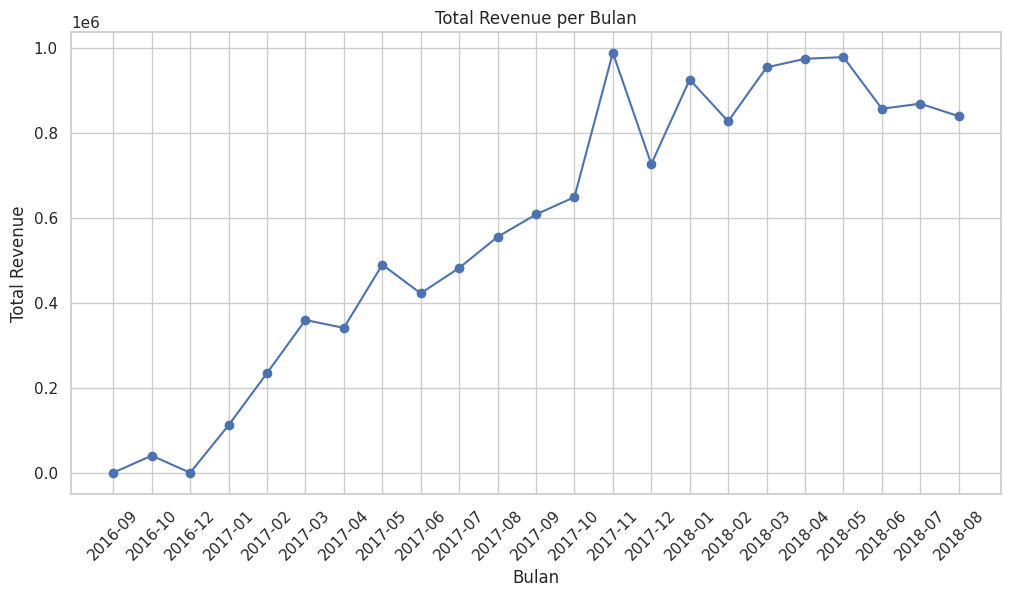

In [21]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['order_month'], monthly_revenue['price'], marker='o')

plt.title('Total Revenue per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

### Pertanyaan 2: Kategori produk apa yang paling banyak terjual?

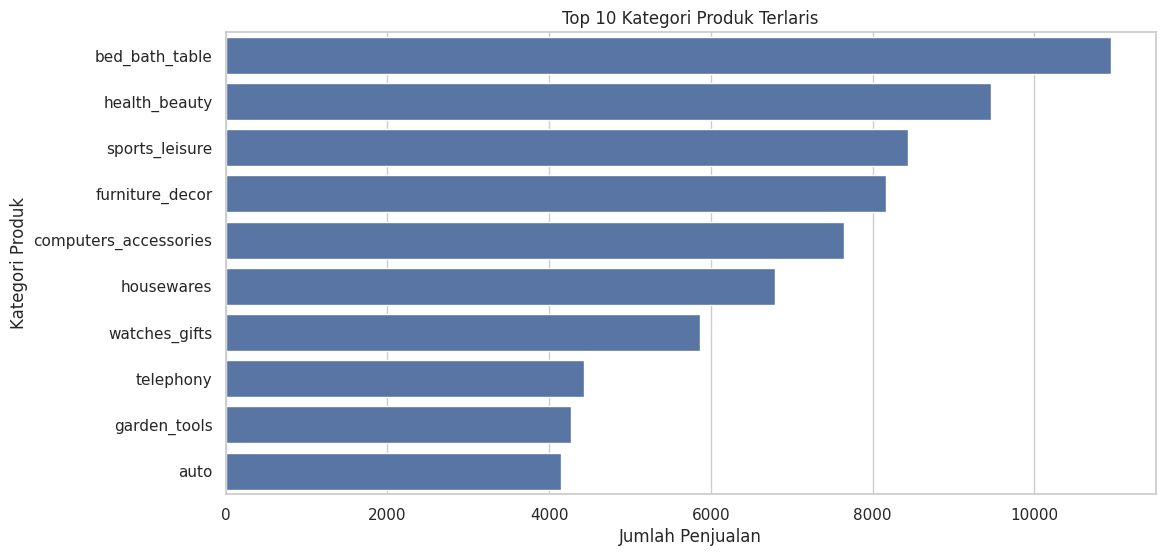

In [22]:
# Ambil top 10 kategori
top_category = category_sales.head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='order_item_id', y='product_category_name_english', data=top_category)

plt.title('Top 10 Kategori Produk Terlaris')
plt.xlabel('Jumlah Penjualan')
plt.ylabel('Kategori Produk')

plt.show()

**Insight:**

- Total revenue menunjukkan adanya fluktuasi penjualan dari waktu ke waktu, dengan beberapa bulan mengalami peningkatan yang signifikan.
- Peningkatan revenue dapat mengindikasikan adanya periode dengan permintaan tinggi, seperti promo atau musim tertentu.
- Kategori produk terlaris didominasi oleh beberapa kategori utama yang memiliki jumlah transaksi jauh lebih tinggi dibandingkan kategori lainnya.
- Hal ini menunjukkan bahwa preferensi pelanggan cenderung terfokus pada kategori tertentu, sehingga dapat menjadi peluang bagi bisnis untuk mengoptimalkan stok dan strategi pemasaran.

## Conclusion

- Conclution pertanyaan 1 : Berdasarkan hasil analisis, total penjualan (revenue) dari waktu ke waktu menunjukkan adanya fluktuasi pada setiap bulan. Beberapa periode mengalami peningkatan revenue yang cukup signifikan, sementara pada periode lainnya terjadi penurunan. Hal ini mengindikasikan bahwa aktivitas penjualan tidak stabil dan kemungkinan dipengaruhi oleh faktor musiman, promosi, atau perilaku pelanggan.

- Conclution pertanyaan 2 : Kategori produk yang paling banyak terjual didominasi oleh beberapa kategori tertentu dengan jumlah transaksi yang jauh lebih tinggi dibandingkan kategori lainnya. Hal ini menunjukkan bahwa preferensi pelanggan cenderung terfokus pada kategori produk tersebut, sehingga dapat menjadi acuan bagi perusahaan dalam menentukan strategi penjualan, pengelolaan stok, dan pemasaran.

In [23]:
# Simpan data hasil olahan untuk dashboard
order_merge.to_csv('/content/drive/MyDrive/DATASET/data-ecommerce/main_data.csv', index=False)